In [1]:
import socket
import torch

print("Hostname:", socket.gethostname())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Hostname: vipa1007
PyTorch: 2.13.0+rocm7.2
CUDA available: True
GPU count: 1
GPU: AMD Instinct MI300A


In [2]:
from torch.utils.data import Dataset
import torch
import math, tifffile, os, time
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import glob
import tifffile as tiff
import os
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
import pandas as pd
from pathlib import Path
import nd2
from ipywidgets import interact, IntSlider, widgets
from ipywidgets import interactive_output
from scipy.ndimage import center_of_mass
from scipy.ndimage import gaussian_filter

In [3]:
nd2_path = "images/20221216 3nM 231-A8_NEMO_TRAF6_1um_38mol 001.nd2"
nd2_array = nd2.imread(nd2_path)
dark_400 = tiff.imread("images/20210531 Darkfield 400ms.tif").astype(np.float32)
dark_60 = tiff.imread("images/20210531 Darkfield 60ms.tif").astype(np.float32)

In [4]:
rfp = np.clip(nd2_array[:,0].astype(np.float32) - dark_400, 0, None) # substracting dark_frame
gfp = np.clip(nd2_array[:,1].astype(np.float32) - dark_60, 0, None)
bf = np.clip(nd2_array[:,2].astype(np.float32) - dark_60, 0, None)

In [7]:
def normalizing_image(img, low, high):
    """normalizing images, to merge same values

    Args:
        img (array): image
        low (float): lowest percentile
        high (float): highes percentile

    Returns:
        Array: the image is normalized
    """
    data_min = np.percentile(img, low, axis = (1,2), keepdims = True)
    data_max = np.percentile(img, high, axis = (1,2), keepdims = True)
    scaled_data = np.clip((img - data_min) / ( data_max - data_min + 1e-8), 0, 1)
    return scaled_data

In [8]:
merge_raw = rfp + gfp
merged_ind_norm = normalizing_image(rfp, 1, 99.8) + normalizing_image(gfp, 1, 99.8)
merged_norm_tog = normalizing_image(rfp + gfp, 1, 99.8)
raw = np.stack([rfp, gfp], axis=0)

In [9]:
def show_Imageminusdarkframe(t):

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # RFP
    axes[0].imshow(
        merged_ind_norm[t],
        cmap="viridis",
        vmin=0,
        vmax=1
    )
    axes[0].set_title("normalizing each challen and then merge")
    axes[0].axis("off")

    # GFP
    axes[1].imshow(
        merged_norm_tog[t],
        cmap="viridis",
        vmin=0,
        vmax= 1
    )
    axes[1].set_title("merge both channels and then normalized")
    axes[1].axis("off")

    # Brightfield
    axes[2].imshow(
        merge_raw[t],
        cmap="viridis",
        vmin=0,
        vmax= 500
    )
    axes[2].set_title("GFP")
    axes[2].axis("off")

    plt.suptitle(f"Timepoint {t}")
    plt.tight_layout()
    plt.show()

play = widgets.Play(
    value=0,
    min=0,
    max=merged_ind_norm.shape[0]-1,
    step=1,
    interval=3      # ms/frame
)

slider = widgets.IntSlider(
    value=300,
    min=0,
    max=merged_ind_norm.shape[0]-1,
    step=1,
    description="Time"
)

widgets.jslink((play, "value"), (slider, "value"))

ui = widgets.HBox([play, slider])
out = interactive_output(show_Imageminusdarkframe, {"t": slider})

display(ui, out)

Output()

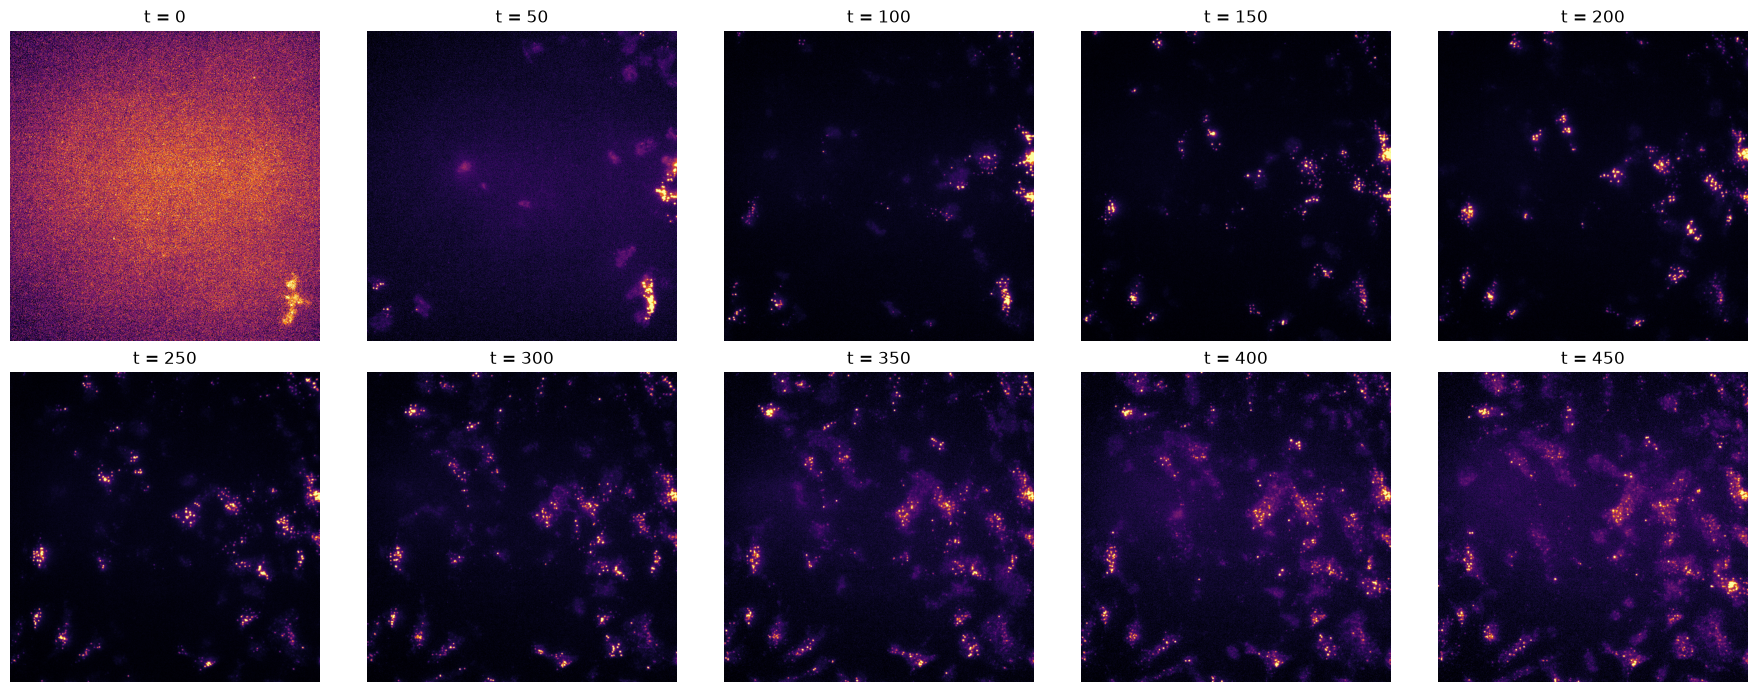

In [10]:
frames = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for ax, t in zip(axes.flat, frames):

    ax.imshow(
        merged_norm_tog[t],
        cmap="inferno",
        vmin=0,
        vmax=1
    )

    ax.set_title(f"t = {t}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
def instance_to_targets(instance_mask, sigma=5):

    foreground = (instance_mask > 0).astype(np.float32)

    centers = np.zeros_like(foreground)

    cell_ids = np.unique(instance_mask)
    cell_ids = cell_ids[cell_ids != 0]

    for cell_id in cell_ids:

        y, x = center_of_mass(
            instance_mask == cell_id
        )

        y = int(round(y))
        x = int(round(x))

        centers[y, x] = 1.0

    centers = gaussian_filter(
        centers,
        sigma=sigma
    )

    if centers.max() > 0:
        centers /= centers.max()

    return foreground, centers

In [14]:
mask = tifffile.imread(
    "cellpose_training/Mask/20221216 3nM 231-A8_NEMO_TRAF6_1um_38mol 001minusdark_0100_masks.tif"
)

foreground, centers = instance_to_targets(mask)

def get_temporal_window(movie, t, radius=2):

    frames = []

    for dt in range(-radius, radius + 1):

        index = np.clip(
            t + dt,
            0,
            movie.shape[0] - 1
        )

        frames.append(movie[index])

    return np.stack(frames, axis=0)

x = get_temporal_window(
    merged_norm_tog,
    t=100,
    radius=1
)

print(x.shape)

(3, 600, 600)


In [15]:
import torch
from torch.utils.data import Dataset


class CellDataset(Dataset):

    def __init__(
        self,
        movie,
        annotation_frames,
        annotation_dir,
        radius=2,
        patch_size=256,
        samples_per_frame=100
    ):

        self.movie = movie
        self.frames = annotation_frames
        self.annotation_dir = annotation_dir

        self.radius = radius
        self.patch_size = patch_size
        self.samples_per_frame = samples_per_frame

    def __len__(self):

        return (
            len(self.frames)
            * self.samples_per_frame
        )

    def __getitem__(self, idx):

        # Choose frame
        frame_index = (
            idx // self.samples_per_frame
        )

        t = self.frames[frame_index]

        # Temporal input
        x = get_temporal_window(
            self.movie,
            t,
            self.radius
        )

        # Load mask
        mask = tifffile.imread(
            f"{self.annotation_dir}/frame_{t:03d}.tif"
        )

        foreground, centers = instance_to_targets(mask)

        # Random crop position
        h, w = foreground.shape
        ps = self.patch_size

        y0 = np.random.randint(0, h - ps)
        x0 = np.random.randint(0, w - ps)

        # Crop input
        x = x[
            :,
            y0:y0 + ps,
            x0:x0 + ps
        ]

        foreground = foreground[
            y0:y0 + ps,
            x0:x0 + ps
        ]

        centers = centers[
            y0:y0 + ps,
            x0:x0 + ps
        ]

        # Augmentation
        if np.random.rand() > 0.5:

            x = np.flip(x, axis=2).copy()

            foreground = np.flip(
                foreground,
                axis=1
            ).copy()

            centers = np.flip(
                centers,
                axis=1
            ).copy()

        if np.random.rand() > 0.5:

            x = np.flip(x, axis=1).copy()

            foreground = np.flip(
                foreground,
                axis=0
            ).copy()

            centers = np.flip(
                centers,
                axis=0
            ).copy()

        x = torch.from_numpy(x).float()

        y = torch.from_numpy(
            np.stack([
                foreground,
                centers
            ])
        ).float()

        return x, y

In [16]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [17]:
class SmallUNet(nn.Module):

    def __init__(self, in_channels=5, out_channels=2):

        super().__init__()

        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(
            256, 128, 2, stride=2
        )

        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, 2, stride=2
        )

        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32, 2, stride=2
        )

        self.dec1 = DoubleConv(64, 32)

        self.output = nn.Conv2d(
            32,
            out_channels,
            1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        b = self.bottleneck(
            self.pool(e3)
        )

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.output(d1)

In [30]:
import torch.nn.functional as F


def dice_loss(pred, target, eps=1e-6):

    pred = torch.sigmoid(pred)

    intersection = (pred * target).sum(dim=(1, 2))

    union = (
        pred.sum(dim=(1, 2))
        + target.sum(dim=(1, 2))
    )

    dice = (
        (2 * intersection + eps)
        / (union + eps)
    )

    return 1 - dice.mean()

def loss_function(pred, target):

    foreground_bce = F.binary_cross_entropy_with_logits(
        pred[:, 0],
        target[:, 0]
    )

    foreground_dice = dice_loss(
        pred[:, 0],
        target[:, 0]
    )

    foreground_loss = (
        foreground_bce
        + foreground_dice
    )

    # Convert center prediction to 0–1
    center_pred = torch.sigmoid(pred[:, 1])

    center_loss = F.mse_loss(
        center_pred,
        target[:, 1]
    )

    return foreground_loss + center_loss

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

model = SmallUNet().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

annotation_frames = [
    10,
    50,
    100,
    150,
    200,
    250,
    300,
    350,
    400,
    450
]

dataset = CellDataset(
    merged_ind_norm,
    annotation_frames,
    "cellpose_training/Cellsegmentation/annotations",
    patch_size=256,
    samples_per_frame=100
)

from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())
print("Device:", device)

Device: cuda
GPU: AMD Instinct MI300A
CUDA available: True
MPS available: False
Device: cuda


In [31]:
print("Device:", device)
print("Model device:", next(model.parameters()).device)

x, y = next(iter(loader))

print("Before transfer:")
print("x:", x.device)
print("y:", y.device)

x = x.to(device)
y = y.to(device)

print("After transfer:")
print("x:", x.device)
print("y:", y.device)

with torch.no_grad():
    pred = model(x)

print("Prediction:", pred.device)

Device: cuda
Model device: cuda:0
Before transfer:
x: cpu
y: cpu
After transfer:
x: cuda:0
y: cuda:0
Prediction: cuda:0


In [32]:
import time

for epoch in range(30):

    model.train()
    epoch_loss = 0
    epoch_start = time.time()

    print(f"\nStarting Epoch {epoch + 1}", flush=True)

    for batch_idx, (x, y) in enumerate(loader):

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        pred = model(x)

        loss = loss_function(pred, y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

        print(
            f"Epoch {epoch + 1}/30 | "
            f"Batch {batch_idx + 1}/{len(loader)} | "
            f"Loss: {loss.item():.4f}",
            end="\r",
            flush=True
        )

    epoch_time = time.time() - epoch_start

    print(
        f"\nEpoch {epoch + 1}/30 finished | "
        f"Average loss: {epoch_loss / len(loader):.4f} | "
        f"Time: {epoch_time:.1f}s",
        flush=True
    )


Starting Epoch 1
Epoch 1/30 | Batch 125/125 | Loss: 1.1971
Epoch 1/30 finished | Average loss: 1.2055 | Time: 9.5s

Starting Epoch 2
Epoch 2/30 | Batch 125/125 | Loss: 0.9796
Epoch 2/30 finished | Average loss: 0.9925 | Time: 9.5s

Starting Epoch 3
Epoch 3/30 | Batch 125/125 | Loss: 0.8422
Epoch 3/30 finished | Average loss: 0.8994 | Time: 9.4s

Starting Epoch 4
Epoch 4/30 | Batch 125/125 | Loss: 0.8125
Epoch 4/30 finished | Average loss: 0.8228 | Time: 9.5s

Starting Epoch 5
Epoch 5/30 | Batch 125/125 | Loss: 0.6872
Epoch 5/30 finished | Average loss: 0.7493 | Time: 9.5s

Starting Epoch 6
Epoch 6/30 | Batch 125/125 | Loss: 0.5856
Epoch 6/30 finished | Average loss: 0.6856 | Time: 9.5s

Starting Epoch 7
Epoch 7/30 | Batch 125/125 | Loss: 0.6113
Epoch 7/30 finished | Average loss: 0.6495 | Time: 9.5s

Starting Epoch 8
Epoch 8/30 | Batch 125/125 | Loss: 0.5338
Epoch 8/30 finished | Average loss: 0.5978 | Time: 9.4s

Starting Epoch 9
Epoch 9/30 | Batch 125/125 | Loss: 0.4337
Epoch 9/30 f

In [33]:
model.eval()

t = 10

x = get_temporal_window(
    merged_ind_norm,
    t,
    radius=2
)

x = torch.from_numpy(
    x[None]
).float().to(device)

with torch.no_grad():

    pred = model(x)

pred = torch.sigmoid(pred)

foreground = pred[0, 0].cpu().numpy()
centers = pred[0, 1].cpu().numpy()

In [34]:
from scipy.ndimage import label
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy.ndimage import distance_transform_edt

cell_mask = foreground > 0.5

# find centers
coordinates = peak_local_max(
    centers,
    min_distance=20,
    threshold_abs=0.3
)

markers = np.zeros_like(
    cell_mask,
    dtype=np.int32
)

for i, (y, x) in enumerate(coordinates, start=1):

    markers[y, x] = i

distance = distance_transform_edt(
    cell_mask
)

labels = watershed(
    -distance,
    markers,
    mask=cell_mask
)

In [35]:
labels.max()

np.int32(3)

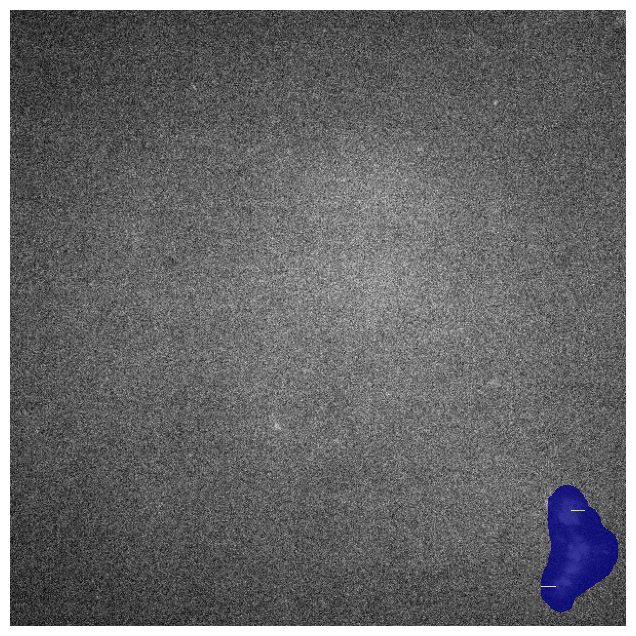

In [36]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# Original image
plt.imshow(
    merged_ind_norm[t],
    cmap="gray"
)

# Make background transparent
labels_masked = np.ma.masked_where(
    labels == 0,
    labels
)

# Overlay cells
plt.imshow(
    labels_masked,
    cmap='gist_ncar',
    alpha=0.8,
    interpolation="none"
)

plt.axis("off")
plt.show()